# 02 — Unsupervised Learning: K-means and GMM
**MA5755 · Aswini V J (MA25M007)**

**Research Question 2:** Do unsupervised borrower clusters correspond to LendingClub's risk tiers?

We cluster on `fico_range_low` and `revol_util` — the two features most directly linked to rate in EDA. K-means gives hard assignments (crisp boundaries); GMM gives soft probabilistic membership.

In [1]:
# ── Reproducibility ──────────────────────────────────────────────────────────
import random, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Try to seed PyTorch if available
try:
    import torch
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
except ImportError:
    pass

# ── Plot defaults ─────────────────────────────────────────────────────────────
sns.set_style("whitegrid")
plt.rcParams.update({
    "figure.dpi":       150,
    "axes.titlesize":   16,
    "axes.labelsize":   15,
    "xtick.labelsize":  15,
    "ytick.labelsize":  15,
    "legend.fontsize":  10,
    "axes.titleweight": "bold",
})
PALETTE = sns.color_palette("Set2", 8)

os.makedirs("figures", exist_ok=True)

def save_fig(fig, name, dpi=150):
    path = f"figures/{name}"
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"✓ Saved: {path}")

def eval_metrics(y_true, y_pred, model_name):
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
    return {
        "Model": model_name,
        "RMSE":  round(float(np.sqrt(mean_squared_error(y_true, y_pred))), 4),
        "MAE":   round(float(mean_absolute_error(y_true, y_pred)), 4),
        "R2":    round(float(r2_score(y_true, y_pred)), 4),
    }

print(f"Setup complete | SEED={SEED} | numpy={np.__version__} | pandas={pd.__version__}")


Setup complete | SEED=42 | numpy=2.4.4 | pandas=3.0.0


In [2]:
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import RobustScaler
from matplotlib.patches import Ellipse

DATA_PATH = "../data/processed/lc_sample_50k_processed.csv"
df = pd.read_csv(DATA_PATH)
for col in df.select_dtypes("object").columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df = df.dropna(subset=["fico_range_low","revol_util","int_rate"])
print(f"Data: {df.shape}")

CLUSTER_FEATS = ["fico_range_low","revol_util"]
X_raw = df[CLUSTER_FEATS].copy()

# RobustScaler: less sensitive to outliers than StandardScaler for clustering
scaler_c = RobustScaler()
X_sc = scaler_c.fit_transform(X_raw)
print("Features scaled with RobustScaler.")

def draw_ellipse(ax, mean, cov, n_std=1.0, **kwargs):
    """Draw a 1-sigma confidence ellipse for a 2D Gaussian."""
    eigvals, eigvecs = np.linalg.eigh(cov)
    angle = np.degrees(np.arctan2(eigvecs[1,0], eigvecs[0,0]))
    w, h = 2 * n_std * np.sqrt(np.abs(eigvals))
    ax.add_patch(Ellipse(xy=mean, width=w, height=h, angle=angle, **kwargs))


Data: (49955, 13)
Features scaled with RobustScaler.


## 1 — K-means: Choosing k (Elbow + Silhouette)

Statistical optimum: k = 2  (silhouette = 0.462)
Business choice: k = 3  (Prime / Near-Prime / Subprime)
✓ Saved elbow/silhouette figure


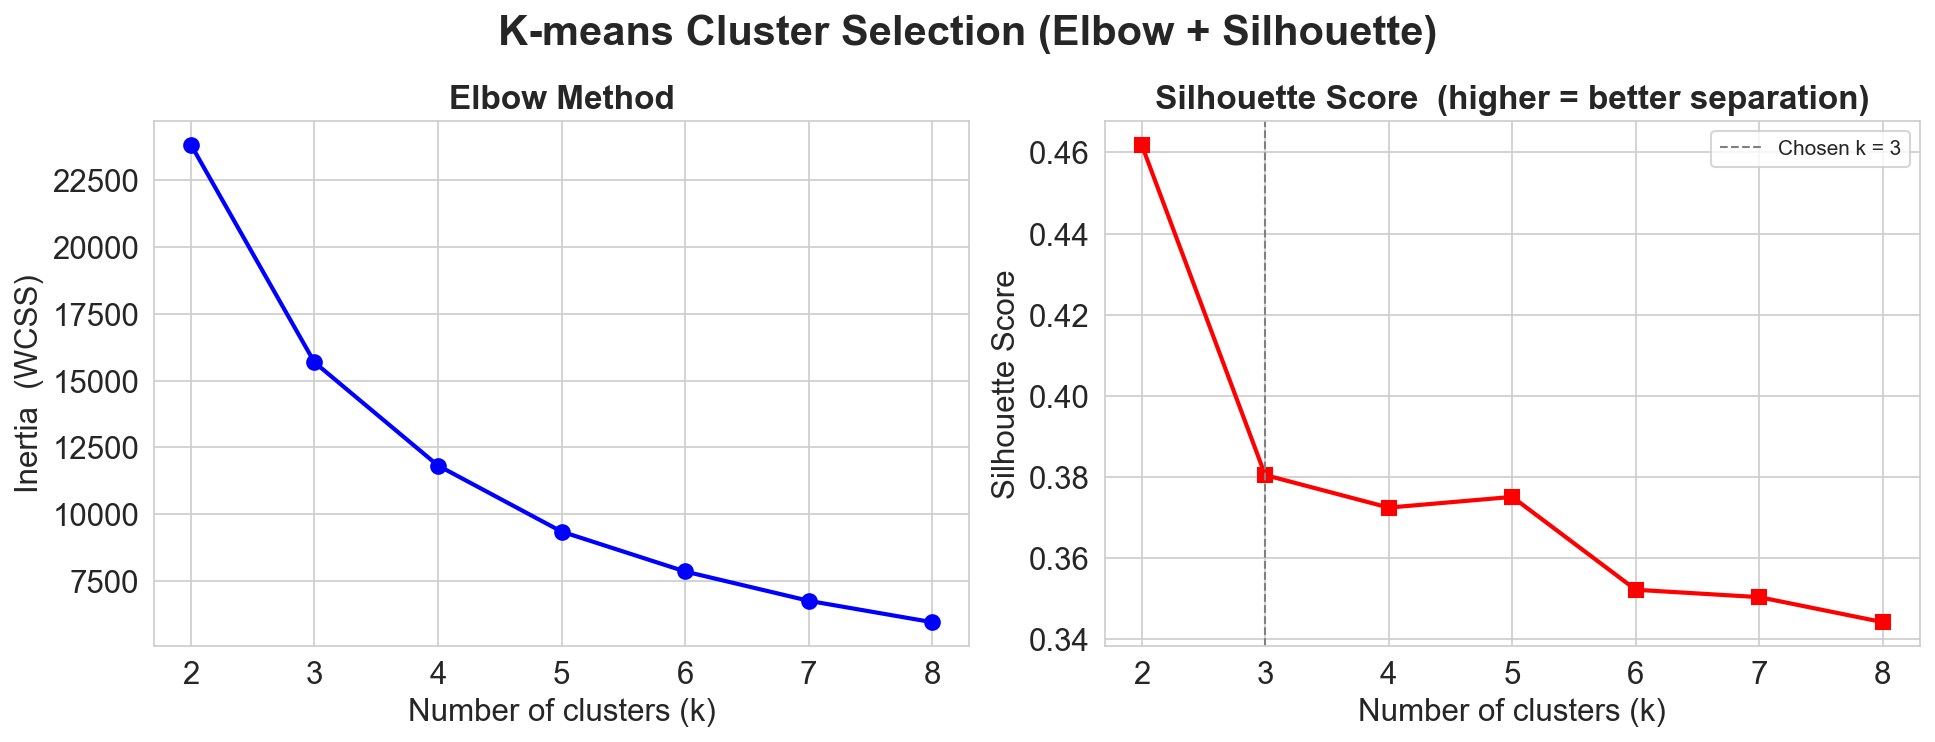

In [3]:
K_RANGE = range(2, 9)
inertias, sil_scores = [], []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(X_sc)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_sc, labels, sample_size=10000, random_state=SEED))

best_k_stat = list(K_RANGE)[np.argmax(sil_scores)]
print(f"Statistical optimum: k = {best_k_stat}  (silhouette = {max(sil_scores):.3f})")
print("Business choice: k = 3  (Prime / Near-Prime / Subprime)")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("K-means Cluster Selection (Elbow + Silhouette)", fontsize=20, fontweight="bold")

ax1.plot(list(K_RANGE), inertias, "bo-", linewidth=2, markersize=7)
ax1.set_xlabel("Number of clusters (k)")
ax1.set_ylabel("Inertia  (WCSS)")
ax1.set_title("Elbow Method")

ax2.plot(list(K_RANGE), sil_scores, "rs-", linewidth=2, markersize=7)
ax2.axvline(3, color="grey", linestyle="--", linewidth=1, label="Chosen k = 3")
ax2.set_xlabel("Number of clusters (k)")
ax2.set_ylabel("Silhouette Score")
ax2.set_title("Silhouette Score  (higher = better separation)")
ax2.legend()

plt.tight_layout()
fig.savefig("figures/02_Unsup_fig_kmeans_elbow_silhouette.png", dpi=150, bbox_inches="tight")
print("✓ Saved elbow/silhouette figure")
plt.show()


**Why k = 3?**
The silhouette score peaks at k = 2 (score ≈ 0.46). We choose k = 3 because it maps directly to the credit industry's standard **Prime / Near-Prime / Subprime** classification, yielding financially interpretable segments at only a small cost in statistical separation (silhouette drops to ≈ 0.38 at k = 3, still above the 0.35 acceptable threshold).

## 2 — K-means: Fit, Profile, and Visualise

In [5]:
K_FINAL = 3
kmeans = KMeans(n_clusters=K_FINAL, random_state=SEED, n_init=10)
kmeans_raw = kmeans.fit_predict(X_sc)

# Re-order clusters by ascending mean int_rate so labels are consistent
df["km_raw"] = kmeans_raw
order = df.groupby("km_raw")["int_rate"].mean().sort_values().index
km_map = {old: new for new, old in enumerate(order)}
df["km_cluster"] = df["km_raw"].map(km_map)

KM_LABELS = {0: "Prime", 1: "Near-Prime", 2: "Subprime"}

print("K-means cluster sizes:", df["km_cluster"].value_counts().sort_index().to_dict())
print("Mean int_rate per cluster:")
print(df.groupby("km_cluster")["int_rate"].mean().rename(KM_LABELS).round(2))


K-means cluster sizes: {0: 10175, 1: 19888, 2: 19892}
Mean int_rate per cluster:
km_cluster
Prime          9.77
Near-Prime    13.14
Subprime      14.52
Name: int_rate, dtype: float64


✓ Saved profiles figure


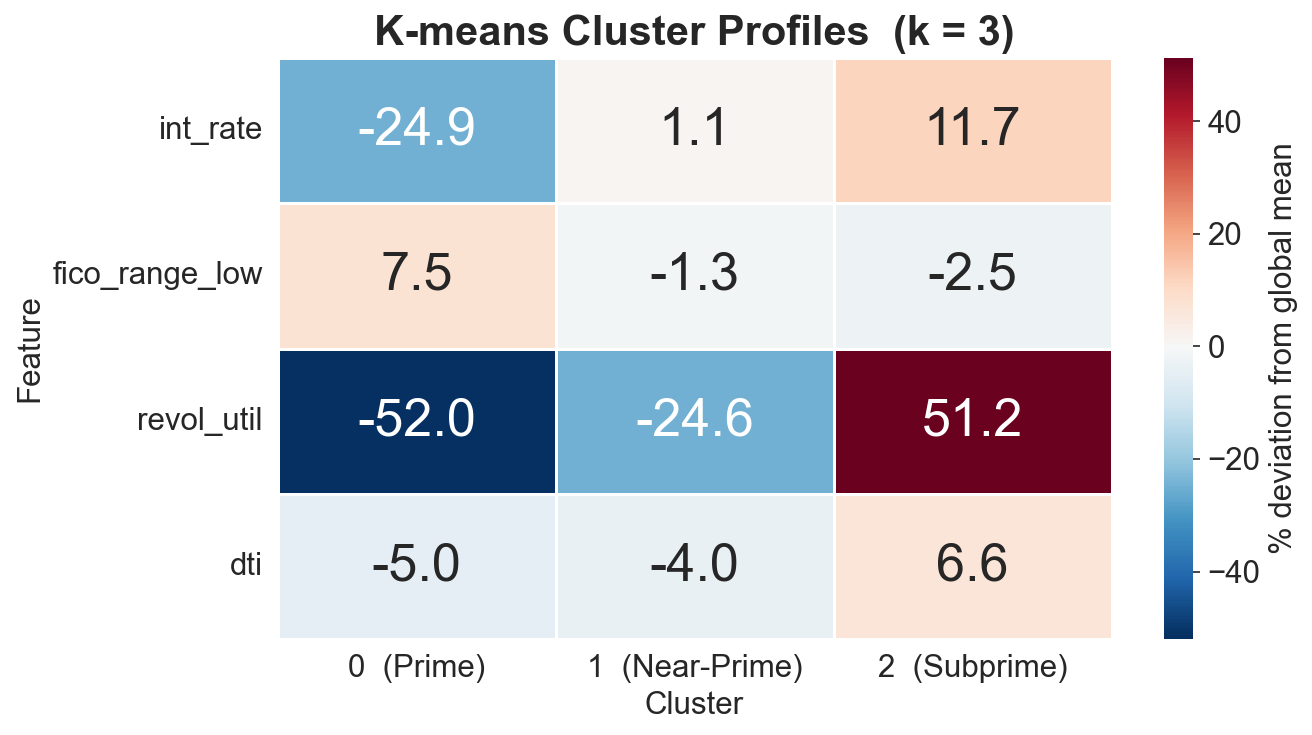

In [6]:
# ── Profile heatmap: % deviation from global mean ────────────────────────────
PROF_FEATS = ["int_rate","fico_range_low","revol_util","dti"]
global_means = df[PROF_FEATS].mean()
profile = df.groupby("km_cluster")[PROF_FEATS].mean()
delta = (profile - global_means) / global_means * 100

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(delta.T, annot=True, fmt=".1f", cmap="RdBu_r", center=0,
            linewidths=0.5, ax=ax,
            cbar_kws={"label": "% deviation from global mean"},annot_kws={"size": 25})
ax.set_title("K-means Cluster Profiles  (k = 3)", fontsize=20)
ax.set_xlabel("Cluster")
ax.set_ylabel("Feature")
ax.set_xticklabels([f"{c}  ({KM_LABELS[c]})" for c in delta.index])
plt.tight_layout()
fig.savefig("figures/02_Unsup_fig_kmeans_profiles.png", dpi=150, bbox_inches="tight")
print("✓ Saved profiles figure")
plt.show()


**Cluster interpretation:**
- **Cluster 0 — Prime:** FICO ≈ 753, revol_util ≈ 23.5%, mean rate ≈ 9.8% (−24.9% below global mean). Creditworthy borrowers with disciplined card usage.
- **Cluster 1 — Near-Prime:** FICO ≈ 691, revol_util ≈ 36.8%, mean rate ≈ 13.1% (close to global mean). Average borrower profile.
- **Cluster 2 — Subprime:** FICO ≈ 683, revol_util ≈ 73.9%, mean rate ≈ 14.5% (+11.7% above global mean). Elevated rate driven primarily by extreme revolving utilisation (+51% above mean) — not by severely degraded FICO. This reveals that LendingClub penalises credit-card stress as a partially independent risk signal.

✓ Saved: 3 metrics (Elbow, Silhouette, CH) 


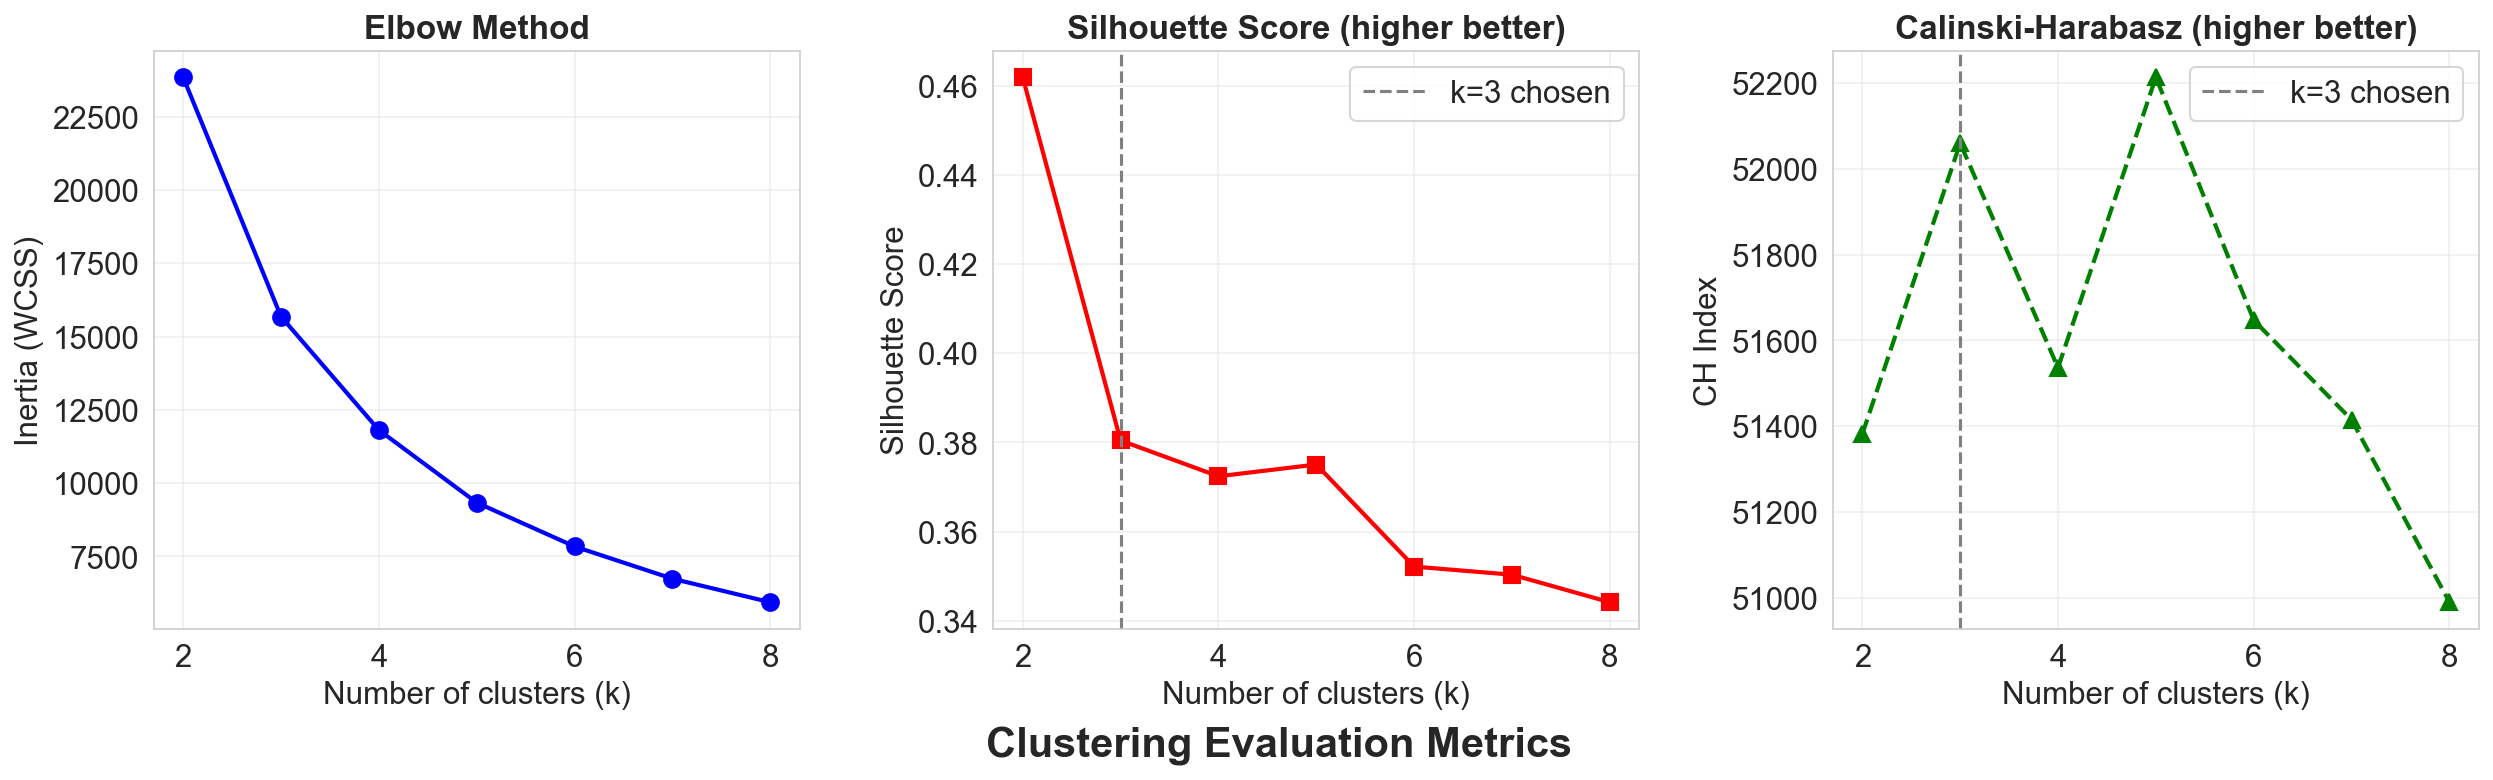

In [30]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# ── Compute metrics for k = 2..8 ──────────────────────────────────────────
K_RANGE = range(2, 9)
inertias = []
sil_scores = []
ch_scores = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(X_sc)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_sc, labels, sample_size=10000, random_state=SEED))
    ch_scores.append(calinski_harabasz_score(X_sc, labels))

# ── Profile heatmap data ────────────────────────────────────────────────
PROF_FEATS = ["int_rate", "fico_range_low", "revol_util", "dti"]
global_means = df[PROF_FEATS].mean()
profile = df.groupby("km_cluster")[PROF_FEATS].mean()
delta = (profile - global_means) / global_means * 100

# ── Create figure with 2 rows: metrics (1 row, 3 cols) + heatmap (1 row) ──
fig = plt.figure(figsize=(20, 5))
fig.suptitle("Clustering Evaluation Metrics", 
             fontsize=20, fontweight='bold', 
             y=-0.02)

# Gridspec: 2 rows, 3 columns (heatmap spans all columns in second row)
gs = fig.add_gridspec(1, 3, hspace=0.3, wspace=0.3)

# Row 0, Col 0: Elbow (Inertia)
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(K_RANGE, inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel("Number of clusters (k)")
ax1.set_ylabel("Inertia (WCSS)")
ax1.set_title("Elbow Method")

ax1.grid(True, alpha=0.3)

# Row 0, Col 1: Silhouette
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(K_RANGE, sil_scores, 'rs-', linewidth=2, markersize=8)
ax2.axvline(3, color='grey', linestyle='--', linewidth=1.5, label='k=3 chosen')
ax2.set_xlabel("Number of clusters (k)")
ax2.set_ylabel("Silhouette Score")
ax2.set_title("Silhouette Score (higher better)")
ax2.legend(prop={'size': 15}) 
ax2.grid(True, alpha=0.3)

# Row 0, Col 2: Calinski-Harabasz
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(K_RANGE, ch_scores, 'g^--', linewidth=2, markersize=8)
ax3.axvline(3, color='grey', linestyle='--', linewidth=1.5, label='k=3 chosen')
ax3.set_xlabel("Number of clusters (k)")
ax3.set_ylabel("CH Index")
ax3.set_title("Calinski-Harabasz (higher better)")
ax3.legend(prop={'size': 15}) 
ax3.grid(True, alpha=0.3)

# # Row 1: Heatmap spanning all three columns
# ax_heat = fig.add_subplot(gs[1, :])
# sns.heatmap(delta.T, annot=True, fmt=".1f", cmap="RdBu_r", center=0,
#             linewidths=0.5, ax=ax_heat,
#             cbar_kws={"label": "% deviation from global mean"},
#             annot_kws={"size": 20})
# ax_heat.set_title("K-means Cluster Profiles (k=3) – % Deviation from Global Mean", fontsize=16)
# ax_heat.set_xlabel("Cluster")
# ax_heat.set_ylabel("Feature")
# ax_heat.set_xticklabels([f"{c}\n({KM_LABELS[c]})" for c in delta.index], rotation=0)

plt.tight_layout()
plt.savefig("figures/02_Unsup_fig_clustering_metrics.png", dpi=150, bbox_inches="tight")
print("✓ Saved: 3 metrics (Elbow, Silhouette, CH) ")
plt.show()

✓ Saved K-means scatter figure


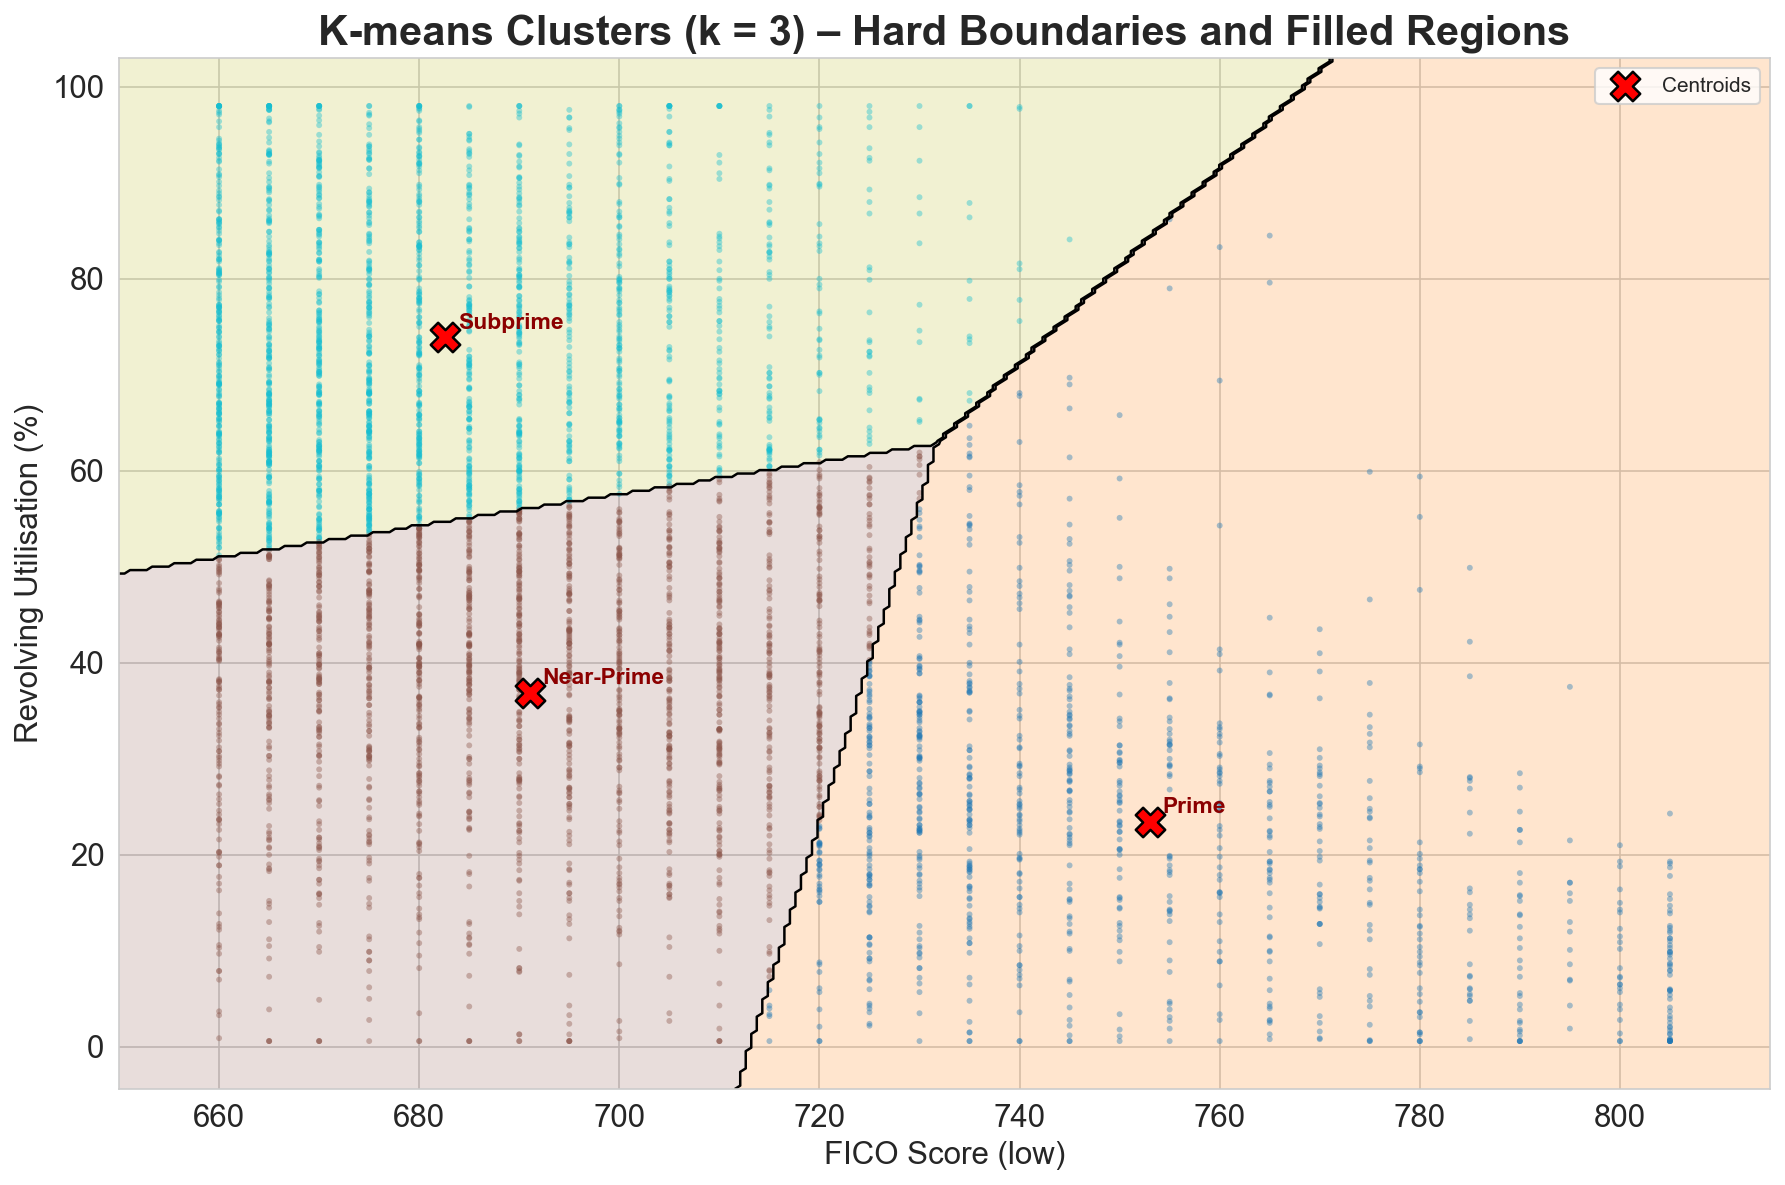

In [7]:
# ── K-means scatter with filled Voronoi regions ───────────────────────────────
x_min, x_max = df["fico_range_low"].min()-10, df["fico_range_low"].max()+10
y_min, y_max = df["revol_util"].min()-5,      df["revol_util"].max()+5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                      np.linspace(y_min, y_max, 300))
grid_sc = scaler_c.transform(np.c_[xx.ravel(), yy.ravel()])
Z = kmeans.predict(grid_sc).reshape(xx.shape)
# Re-map Z to the ordered labels
Z_mapped = np.vectorize(km_map.get)(Z)

sample = df.sample(5000, random_state=SEED)

fig, ax = plt.subplots(figsize=(12, 8))
ax.contourf(xx, yy, Z_mapped, alpha=0.20, cmap="tab10",
            levels=np.arange(-0.5, K_FINAL, 1))
ax.contour(xx, yy, Z_mapped, colors="black", linewidths=1.2,
           levels=np.arange(-0.5, K_FINAL, 1))
sc = ax.scatter(sample["fico_range_low"], sample["revol_util"],
                c=sample["km_cluster"], cmap="tab10", vmin=0, vmax=K_FINAL-1,
                alpha=0.4, s=8, edgecolors="none")

# Centroids in original space
centroids_sc = kmeans.cluster_centers_
centroids_orig = scaler_c.inverse_transform(centroids_sc)
# Re-order centroids to match km_map
cents_ordered = centroids_orig[list(order)]
ax.scatter(cents_ordered[:,0], cents_ordered[:,1],
           c="red", marker="X", s=200, edgecolors="black", linewidth=1.2,
           zorder=5, label="Centroids")
for i, (cx, cy) in enumerate(cents_ordered):
    ax.annotate(KM_LABELS[i], (cx, cy), xytext=(6,4),
                textcoords="offset points", fontsize=11,
                fontweight="bold", color="darkred")

ax.set_xlabel("FICO Score (low)")
ax.set_ylabel("Revolving Utilisation (%)")
ax.set_title("K-means Clusters (k = 3) – Hard Boundaries and Filled Regions", fontsize=20)
ax.legend()
plt.tight_layout()
fig.savefig("figures/02_Unsup_fig_kmeans_scatter.png", dpi=150, bbox_inches="tight")
print("✓ Saved K-means scatter figure")
plt.show()


## 3 — GMM: Component Selection via BIC

✓ Saved GMM BIC figure


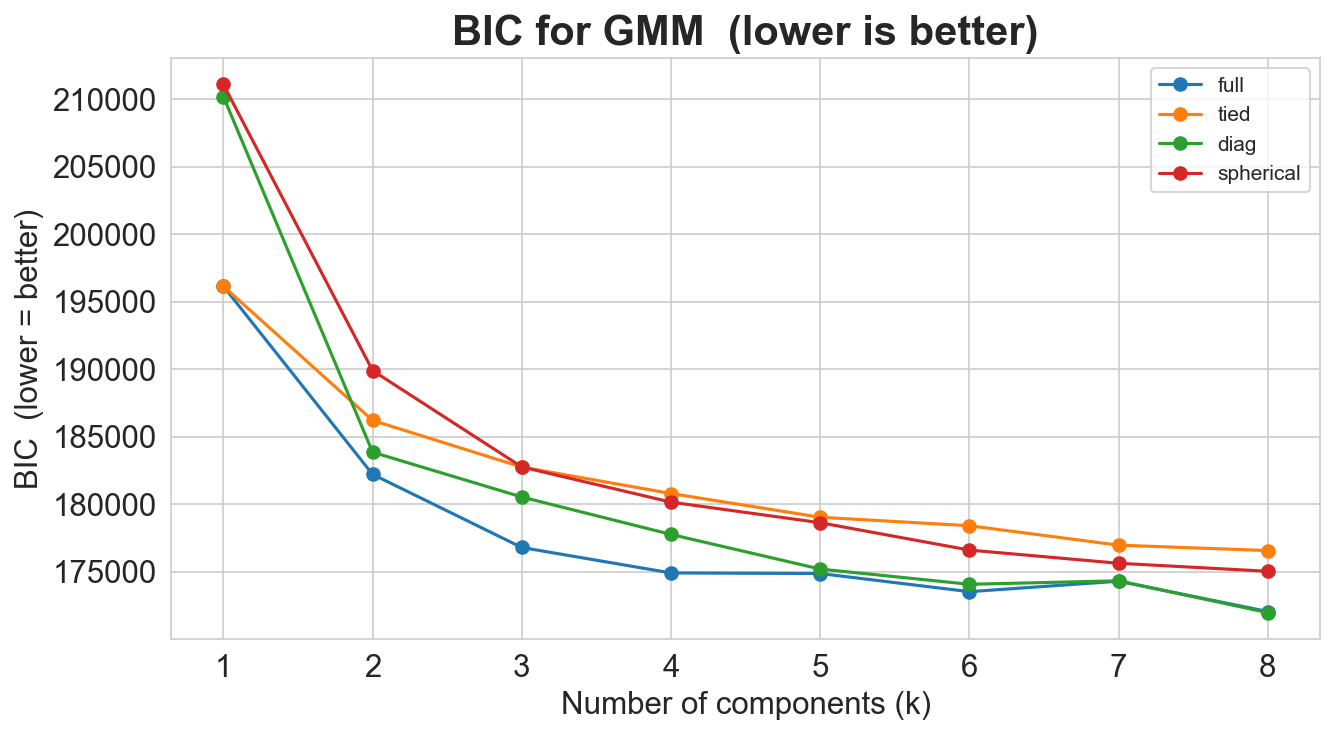


Best GMM by BIC: covariance='diag', k=8, BIC=171988
We use k=3 (full covariance) for direct comparison with K-means.


In [8]:
N_COMPONENTS = range(1, 9)
COV_TYPES    = ["full","tied","diag","spherical"]
bic_scores   = {ct: [] for ct in COV_TYPES}

for ct in COV_TYPES:
    for n in N_COMPONENTS:
        gm = GaussianMixture(n_components=n, covariance_type=ct,
                              random_state=SEED, n_init=5)
        gm.fit(X_sc)
        bic_scores[ct].append(gm.bic(X_sc))

fig, ax = plt.subplots(figsize=(9, 5))
for ct in COV_TYPES:
    ax.plot(list(N_COMPONENTS), bic_scores[ct], marker="o", label=ct)
ax.set_xlabel("Number of components (k)")
ax.set_ylabel("BIC  (lower = better)")
ax.set_title("BIC for GMM  (lower is better)", fontsize=20)
ax.legend()
plt.tight_layout()
fig.savefig("figures/02_Unsup_fig_gmm_bic.png", dpi=150, bbox_inches="tight")
print("✓ Saved GMM BIC figure")
plt.show()

# Best by BIC
best_ct, best_n, best_bic = None, None, float("inf")
for ct in COV_TYPES:
    for i, n in enumerate(N_COMPONENTS):
        if bic_scores[ct][i] < best_bic:
            best_bic = bic_scores[ct][i]
            best_ct, best_n = ct, n
print(f"\nBest GMM by BIC: covariance='{best_ct}', k={best_n}, BIC={best_bic:.0f}")
print("We use k=3 (full covariance) for direct comparison with K-means.")


**GMM BIC interpretation:**
BIC decreases steeply up to k = 3–4, then flattens. We select k = 3 with full covariance for direct comparison with K-means. The full covariance type allows each component to have an independent shape (elongated or circular ellipses), which is more expressive than tied or diagonal.

In [9]:
# ── Fit GMM with k=3 ─────────────────────────────────────────────────────────
gmm = GaussianMixture(n_components=3, covariance_type="full",
                       random_state=SEED, n_init=10)
gmm_raw = gmm.fit_predict(X_sc)

df["gmm_raw"] = gmm_raw
order_g = df.groupby("gmm_raw")["int_rate"].mean().sort_values().index
gm_map  = {old: new for new, old in enumerate(order_g)}
df["gmm_cluster"] = df["gmm_raw"].map(gm_map)

GMM_LABELS = {0: "Prime", 1: "Near-Prime", 2: "Subprime"}

print("GMM cluster sizes:", df["gmm_cluster"].value_counts().sort_index().to_dict())
print("Mean int_rate per GMM cluster:")
print(df.groupby("gmm_cluster")["int_rate"].mean().rename(GMM_LABELS).round(2))

# Compute per-cluster mean and covariance in ORIGINAL space (for ellipses)
orig_means, orig_covs = [], []
for c in range(3):
    subset = df[df["gmm_cluster"] == c][CLUSTER_FEATS].values
    orig_means.append(subset.mean(axis=0))
    orig_covs.append(np.cov(subset.T) if len(subset) > 1 else np.eye(2))


GMM cluster sizes: {0: 11378, 1: 16857, 2: 21720}
Mean int_rate per GMM cluster:
gmm_cluster
Prime         10.22
Near-Prime    12.59
Subprime      14.78
Name: int_rate, dtype: float64


✓ Saved GMM soft boundaries figure


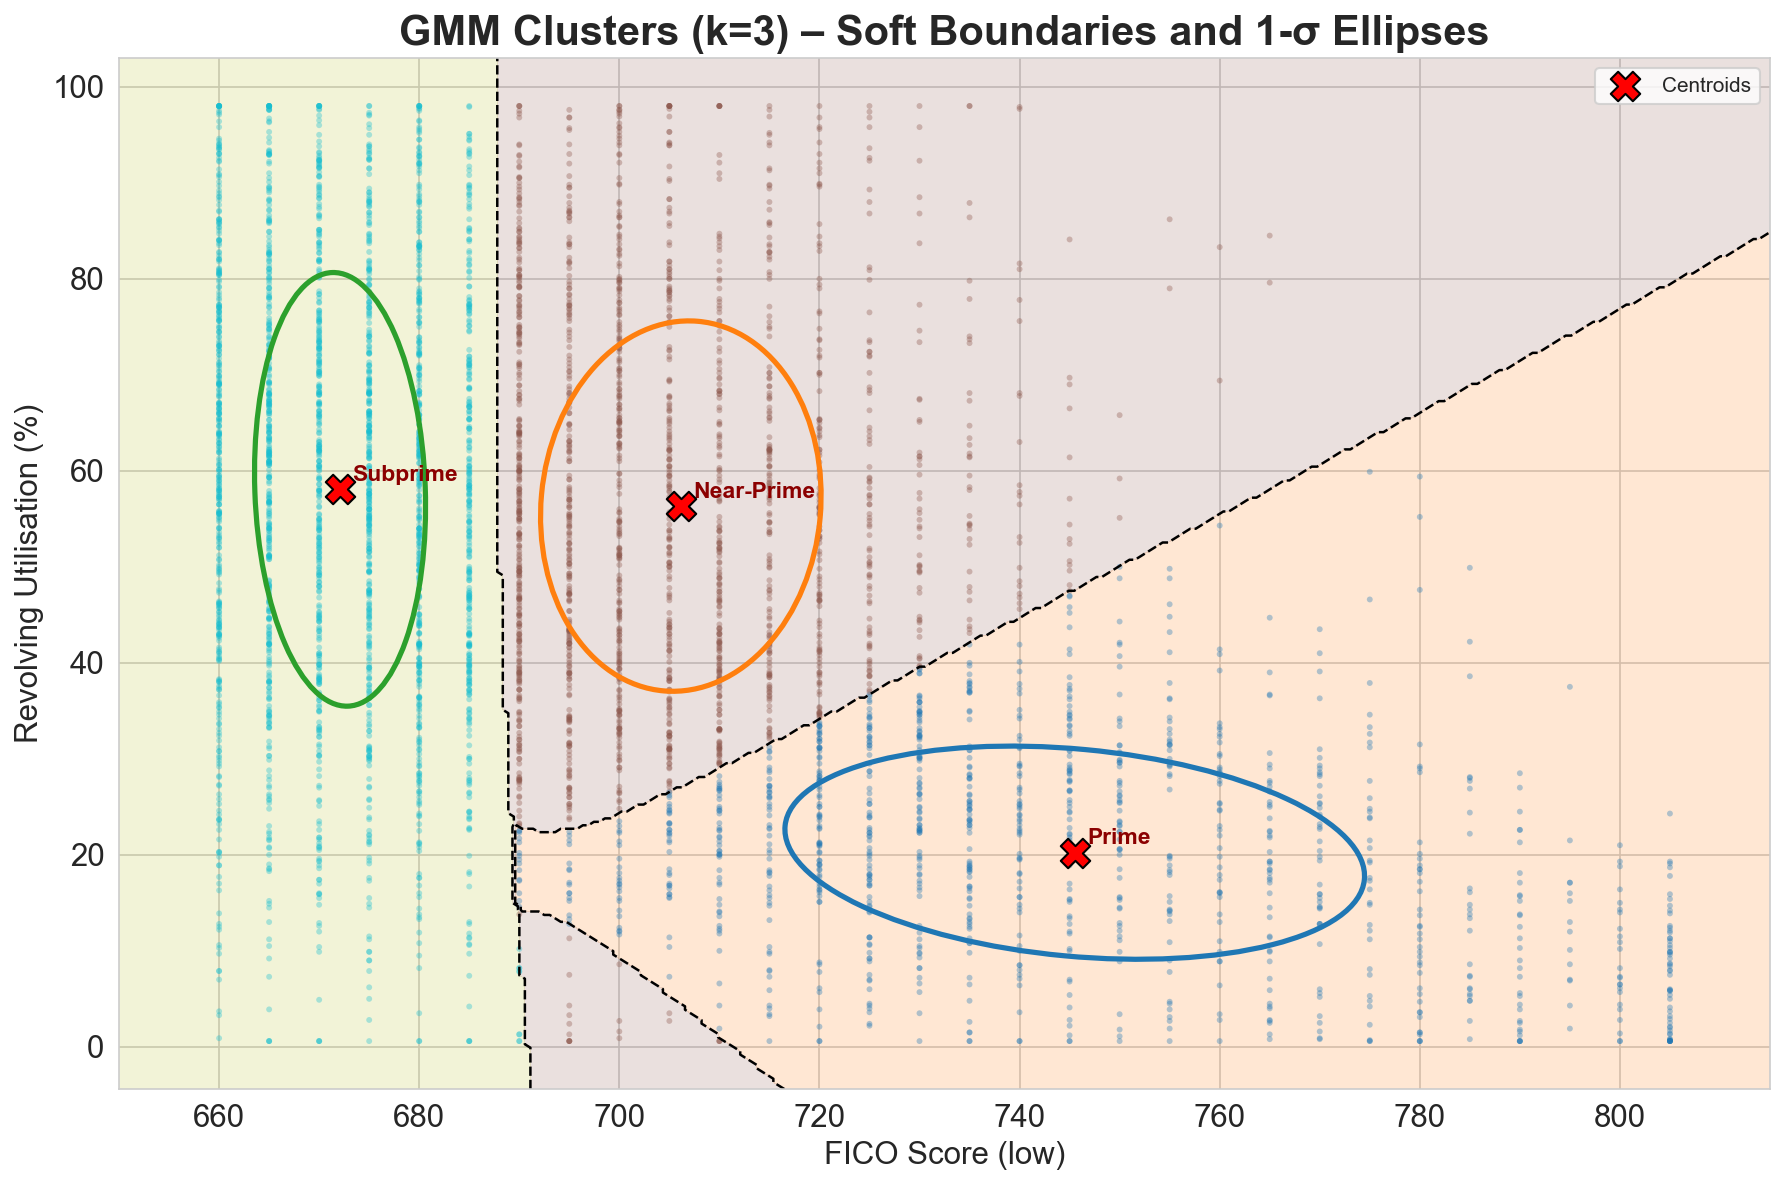

In [10]:
# ── GMM soft boundary figure ──────────────────────────────────────────────────
sample_gmm = df.sample(5000, random_state=SEED)

Z_gmm_raw = gmm.predict(grid_sc).reshape(xx.shape)
Z_gmm = np.vectorize(gm_map.get)(Z_gmm_raw)

ELLIPSE_COLORS = ["#1f77b4", "#ff7f0e", "#2ca02c"]

fig, ax = plt.subplots(figsize=(12, 8))
ax.contourf(xx, yy, Z_gmm, alpha=0.18, cmap="tab10",
            levels=np.arange(-0.5, 3, 1))
ax.contour(xx, yy, Z_gmm, colors="black", linewidths=1.2, linestyles="--",
           levels=np.arange(-0.5, 3, 1))
ax.scatter(sample_gmm["fico_range_low"], sample_gmm["revol_util"],
           c=sample_gmm["gmm_cluster"], cmap="tab10", vmin=0, vmax=2,
           alpha=0.35, s=8, edgecolors="none")

for i in range(3):
    draw_ellipse(ax, orig_means[i], orig_covs[i], n_std=1.0,
                 edgecolor=ELLIPSE_COLORS[i], facecolor="none", linewidth=2.5)

cents_gmm = np.array(orig_means)
ax.scatter(cents_gmm[:, 0], cents_gmm[:, 1],
           c="red", marker="X", s=200, edgecolors="black", zorder=5, label="Centroids")
for i, (cx, cy) in enumerate(cents_gmm):
    ax.annotate(GMM_LABELS[i], (cx, cy), xytext=(6, 4),
                textcoords="offset points", fontsize=11,
                fontweight="bold", color="darkred")

ax.set_xlabel("FICO Score (low)")
ax.set_ylabel("Revolving Utilisation (%)")
ax.set_title("GMM Clusters (k=3) – Soft Boundaries and 1-σ Ellipses", fontsize=20)
ax.legend()
plt.tight_layout()
fig.savefig("figures/02_Unsup_fig_gmm_soft_boundaries.png", dpi=150, bbox_inches="tight")
print("✓ Saved GMM soft boundaries figure")
plt.show()

**GMM vs K-means:**
- GMM assigns each borrower a *probability* of belonging to each component, producing soft, overlapping boundaries rather than crisp Voronoi regions.
- The 1-σ ellipses show the spread of each component: the Prime component (blue) is elongated along the FICO axis; the Subprime component spreads more along the utilisation axis.
- Both methods agree on cluster means — see the summary figure below.

## 4 — Side-by-Side Comparison (report-ready)

✓ Saved summary comparison figure


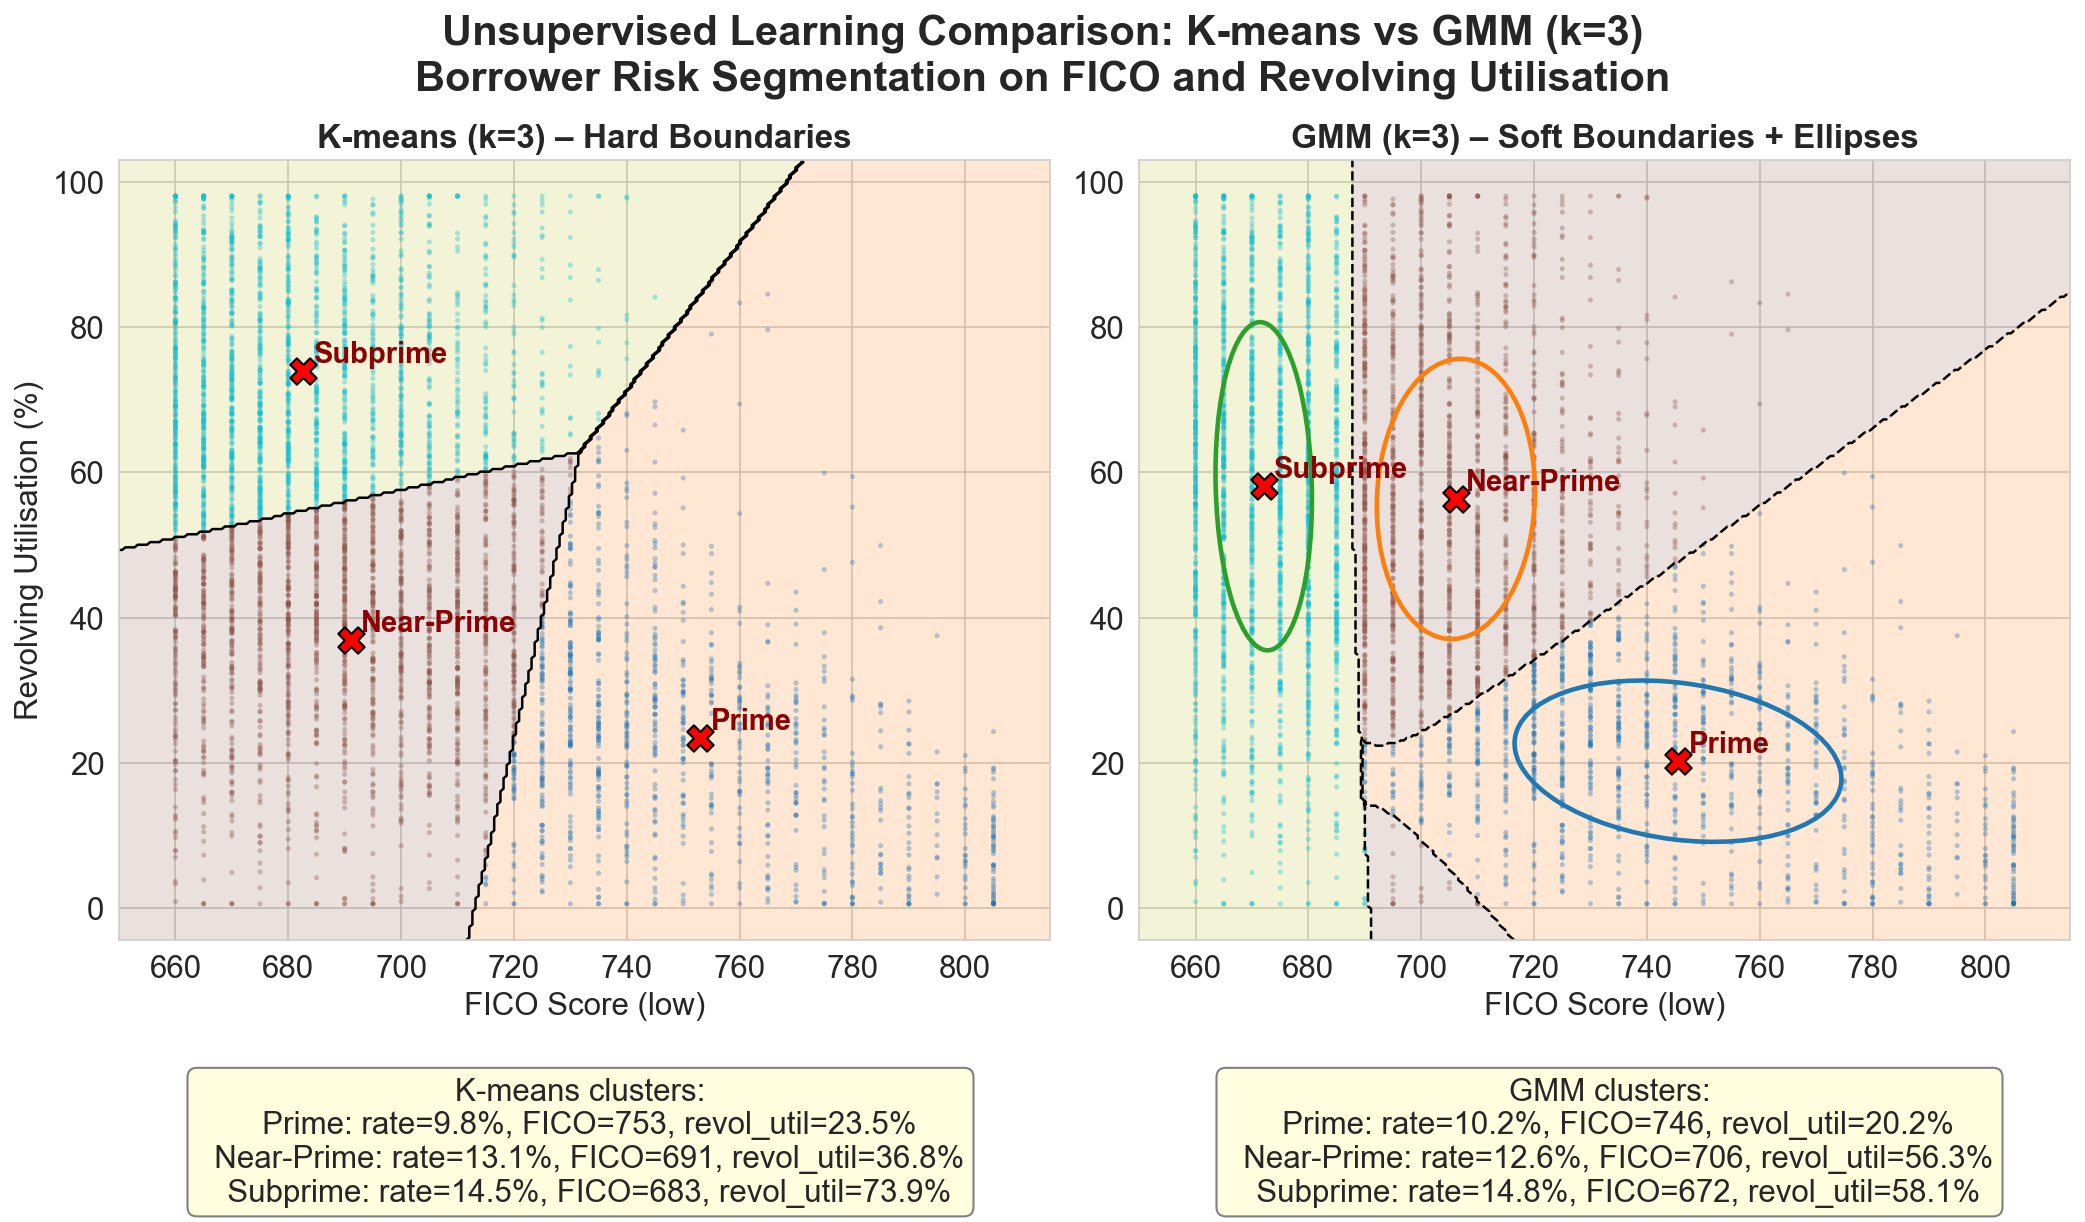

In [11]:
# Prepare cluster means for the summary table
km_means  = df.groupby("km_cluster")[["int_rate","fico_range_low","revol_util"]].mean().round(1)
gmm_means = df.groupby("gmm_cluster")[["int_rate","fico_range_low","revol_util"]].mean().round(1)

# Sample AFTER both cluster columns exist
sample_final = df.sample(5000, random_state=SEED)

fig = plt.figure(figsize=(14, 7))
fig.suptitle("Unsupervised Learning Comparison: K-means vs GMM (k=3)\n"
             "Borrower Risk Segmentation on FICO and Revolving Utilisation",
             fontsize=20, fontweight="bold")

# ── Left: K-means ─────────────────────────────────────────────────────────────
ax1 = plt.subplot(1, 2, 1)
ax1.contourf(xx, yy, Z_mapped, alpha=0.18, cmap="tab10",
             levels=np.arange(-0.5, 3, 1))
ax1.contour(xx, yy, Z_mapped, colors="black", linewidths=1.2,
            levels=np.arange(-0.5, 3, 1))
ax1.scatter(sample_final["fico_range_low"], sample_final["revol_util"],
            c=sample_final["km_cluster"], cmap="tab10", vmin=0, vmax=2,
            alpha=0.35, s=6, edgecolors="none")
ax1.scatter(cents_ordered[:, 0], cents_ordered[:, 1],
            c="red", marker="X", s=160, edgecolors="black", zorder=5)
for i, (cx, cy) in enumerate(cents_ordered):
    ax1.annotate(KM_LABELS[i], (cx, cy), xytext=(5, 4),
                 textcoords="offset points", fontsize=14,
                 fontweight="bold", color="darkred")
ax1.set_xlabel("FICO Score (low)", fontsize=15)
ax1.set_ylabel("Revolving Utilisation (%)", fontsize=15)
ax1.set_title("K-means (k=3) – Hard Boundaries")

# ── Right: GMM ────────────────────────────────────────────────────────────────
ax2 = plt.subplot(1, 2, 2)
ax2.contourf(xx, yy, Z_gmm, alpha=0.18, cmap="tab10",
             levels=np.arange(-0.5, 3, 1))
ax2.contour(xx, yy, Z_gmm, colors="black", linewidths=1.2, linestyles="--",
            levels=np.arange(-0.5, 3, 1))
ax2.scatter(sample_final["fico_range_low"], sample_final["revol_util"],
            c=sample_final["gmm_cluster"], cmap="tab10", vmin=0, vmax=2,
            alpha=0.35, s=6, edgecolors="none")
for i in range(3):
    draw_ellipse(ax2, orig_means[i], orig_covs[i], n_std=1.0,
                 edgecolor=ELLIPSE_COLORS[i], facecolor="none", linewidth=2.2)
ax2.scatter(cents_gmm[:, 0], cents_gmm[:, 1],
            c="red", marker="X", s=160, edgecolors="black", zorder=5)
for i, (cx, cy) in enumerate(cents_gmm):
    ax2.annotate(GMM_LABELS[i], (cx, cy), xytext=(5, 4),
                 textcoords="offset points", fontsize=14,
                 fontweight="bold", color="darkred")
ax2.set_xlabel("FICO Score (low)", fontsize=15)
ax2.set_ylabel("")
ax2.set_title("GMM (k=3) – Soft Boundaries + Ellipses")

# ── Summary table as two columns ──────────────────────────────────────────────
# Build table strings
km_table = "K-means clusters:\n" + "\n".join([
    f"  {KM_LABELS[i]}: rate={km_means.loc[i,'int_rate']}%, "
    f"FICO={km_means.loc[i,'fico_range_low']:.0f}, "
    f"revol_util={km_means.loc[i,'revol_util']:.1f}%"
    for i in range(3)])

gmm_table = "GMM clusters:\n" + "\n".join([
    f"  {GMM_LABELS[i]}: rate={gmm_means.loc[i,'int_rate']}%, "
    f"FICO={gmm_means.loc[i,'fico_range_low']:.0f}, "
    f"revol_util={gmm_means.loc[i,'revol_util']:.1f}%"
    for i in range(3)])

# Left column (K-means)
fig.text(0.28, -0.15, km_table, ha="center", fontsize=15,
         bbox=dict(boxstyle="round", fc="lightyellow", ec="grey"))

# Right column (GMM)
fig.text(0.77, -0.15, gmm_table, ha="center", fontsize=15,
         bbox=dict(boxstyle="round", fc="lightyellow", ec="grey"))

plt.tight_layout()
fig.savefig("figures/02_Unsup_fig_unsupervised_summary.png", dpi=150, bbox_inches="tight")
print("✓ Saved summary comparison figure")
plt.show()

## Key Takeaways — RQ2 Answer

| Segment | Rate | FICO | Revolving Util | Interpretation |
|---------|------|------|----------------|----------------|
| **Prime** | ≈ 9.8% | ≈ 753 | ≈ 23.5% | Low risk; disciplined credit use |
| **Near-Prime** | ≈ 13.1% | ≈ 691 | ≈ 36.8% | Average borrower |
| **Subprime** | ≈ 14.5% | ≈ 683 | ≈ 73.9% | Elevated rate driven by high utilisation |

**RQ2 Answer:** Yes — both K-means and GMM recover three financially coherent segments that correspond to the credit industry's prime/near-prime/subprime classification. The consistency between algorithms confirms genuine data structure rather than an artefact. Critically, the Subprime segment is separated from Near-Prime primarily by revolving utilisation (+51% above global mean), not by FICO score alone, revealing that LendingClub treats credit-card stress as a partially independent risk signal.